# Memphis 

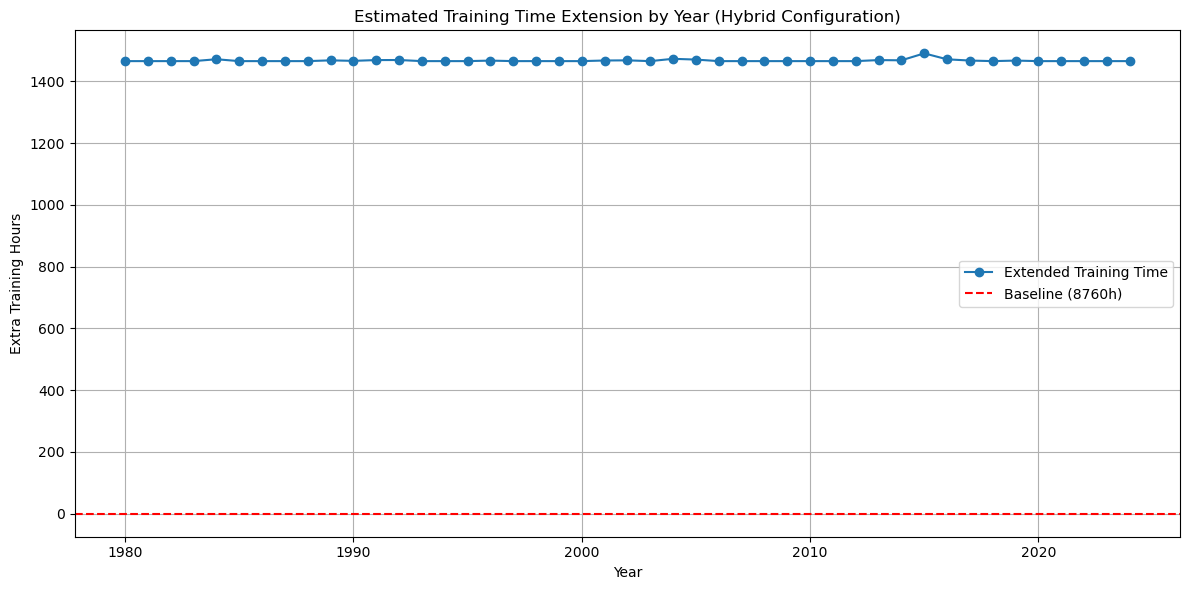


Average Extra Training Time (1980–2024): 1467.59 hours
1980: 1465.91 extra training hours
1981: 1465.91 extra training hours
1982: 1465.91 extra training hours
1983: 1465.91 extra training hours
1984: 1471.99 extra training hours
1985: 1465.91 extra training hours
1986: 1465.91 extra training hours
1987: 1465.91 extra training hours
1988: 1465.91 extra training hours
1989: 1468.41 extra training hours
1990: 1466.74 extra training hours
1991: 1469.28 extra training hours
1992: 1469.49 extra training hours
1993: 1465.91 extra training hours
1994: 1465.91 extra training hours
1995: 1465.91 extra training hours
1996: 1467.57 extra training hours
1997: 1465.91 extra training hours
1998: 1465.93 extra training hours
1999: 1465.91 extra training hours
2000: 1465.91 extra training hours
2001: 1467.92 extra training hours
2002: 1468.41 extra training hours
2003: 1465.91 extra training hours
2004: 1473.40 extra training hours
2005: 1470.90 extra training hours
2006: 1465.91 extra training hours

In [16]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# === File Directory Configuration ===
folder_path = r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_55_percent_inference"
years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250

interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

# === Helper Function ===
def get_training_extension(power_percent):
    power_percent = np.clip(power_percent, 0, 100)  # Keep between 0 and 100%
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

# === Results Storage ===
yearly_extension_hours = {}

# === Process Each Year ===
for year in years:
    file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
    try:
        df = pd.read_csv(file_path)

        # Calculate original available power
        df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100
        df['Power Available (%)'] = 100 - df['Unmet (%)']

        # === NEW COLUMN: subtract 43% and clip at 0 ===
        df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - 43, 0, 100)

        # Use adjusted column to calculate training extension
        df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(
            lambda p: 2.0 if p < (100 / 250 * 100) else get_training_extension(p)
        )
        df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1

        # Save CSV
        columns_to_save = [
            'Hour', 'Load (kW)', 'Unmet (kW)', 'Unmet (%)',
            'Power Available (%)', 'Power Available Adjusted (%)',
            'Training Time Extension (×)', 'Extra Training Hours'
        ]
        result = df[columns_to_save]
        save_path = os.path.join(folder_path, f"training_extension_{year}.csv")
        result.to_csv(save_path, index=False)

        # Total extra training hours
        total_extra = result['Extra Training Hours'].sum()
        yearly_extension_hours[year] = total_extra

    except FileNotFoundError:
        print(f"File not found for year {year}")
        yearly_extension_hours[year] = None

# === Plotting ===
years_sorted = sorted(yearly_extension_hours.keys())
extension_values = [yearly_extension_hours[y] if yearly_extension_hours[y] is not None else 0 for y in years_sorted]

plt.figure(figsize=(12, 6))
plt.plot(years_sorted, extension_values, marker='o', label='Extended Training Time')
plt.title("Estimated Training Time Extension by Year (Hybrid Configuration)")
plt.xlabel("Year")
plt.ylabel("Extra Training Hours")
plt.axhline(0, color='red', linestyle='--', label='Baseline (8760h)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

average_extension = np.mean([v for v in yearly_extension_hours.values() if v is not None])
print(f"\nAverage Extra Training Time (1980–2024): {average_extension:.2f} hours")

# === Print Extension Summary ===
for year in years_sorted:
    if yearly_extension_hours[year] is not None:
        print(f"{year}: {yearly_extension_hours[year]:.2f} extra training hours")
    else:
        print(f"{year}: File missing")


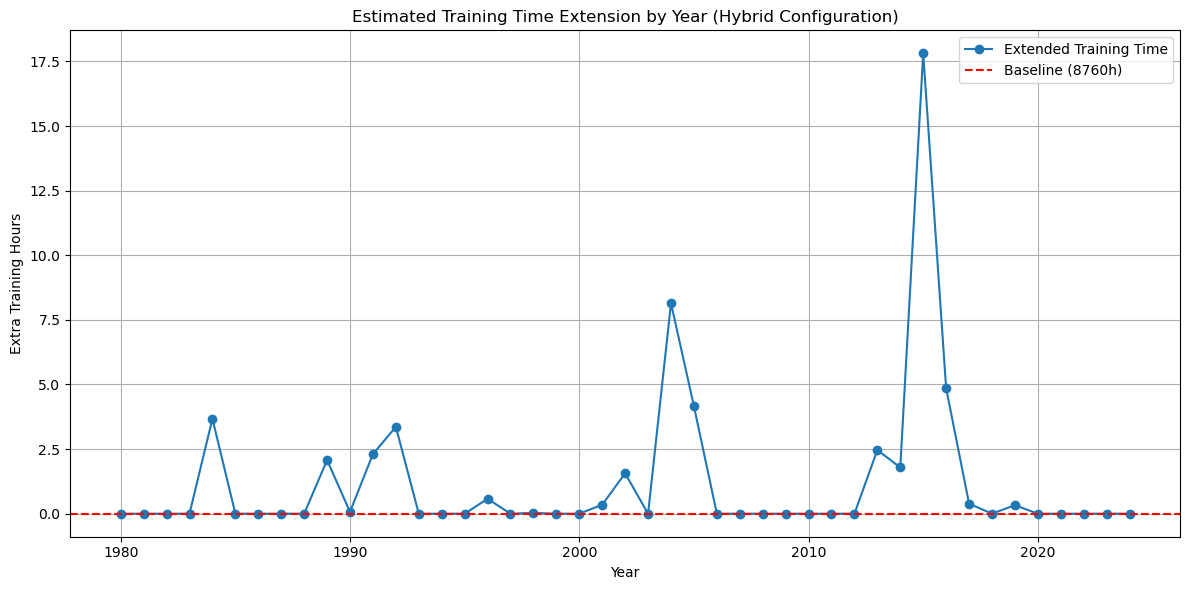


Average Extra Training Time (1980–2024): 1.20 hours
1980: 0.00 extra training hours
1981: 0.00 extra training hours
1982: 0.00 extra training hours
1983: 0.00 extra training hours
1984: 3.67 extra training hours
1985: 0.00 extra training hours
1986: 0.00 extra training hours
1987: 0.00 extra training hours
1988: 0.00 extra training hours
1989: 2.07 extra training hours
1990: 0.07 extra training hours
1991: 2.31 extra training hours
1992: 3.36 extra training hours
1993: 0.00 extra training hours
1994: 0.00 extra training hours
1995: 0.00 extra training hours
1996: 0.58 extra training hours
1997: 0.00 extra training hours
1998: 0.03 extra training hours
1999: 0.00 extra training hours
2000: 0.00 extra training hours
2001: 0.35 extra training hours
2002: 1.56 extra training hours
2003: 0.00 extra training hours
2004: 8.14 extra training hours
2005: 4.16 extra training hours
2006: 0.00 extra training hours
2007: 0.00 extra training hours
2008: 0.00 extra training hours
2009: 0.00 extra tr

In [18]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# === File Directory Configuration ===
folder_path = r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_55_percent_inference"
years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250

interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

# === Helper Function ===
def get_training_extension(power_percent):
    power_percent = np.clip(power_percent, 0, 100)
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

# === Results Storage ===
yearly_extension_hours = {}

# === Process Each Year ===
for year in years:
    file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
    try:
        df = pd.read_csv(file_path)
        unmet_rows = df[df['Unmet (kW)'] > 0].copy()

        if unmet_rows.empty:
            yearly_extension_hours[year] = 0
            continue

        unmet_rows['Unmet (%)'] = (unmet_rows['Unmet (kW)'] / unmet_rows['Load (kW)']) * 100
        unmet_rows['Power Available (%)'] = 100 - unmet_rows['Unmet (%)']
                                        # Apply training extension rule
        unmet_rows['Training Time Extension (×)'] = unmet_rows['Power Available (%)'].apply(
            lambda p: 2.0 if p < (100 / 250 * 100) else get_training_extension(p)
         )
        unmet_rows['Extra Training Hours'] = unmet_rows['Training Time Extension (×)'] - 1




        columns_to_save = [
            'Hour', 'Load (kW)', 'Unmet (kW)', 'Unmet (%)',
            'Power Available (%)', 'Training Time Extension (×)', 'Extra Training Hours'
        ]
        result = unmet_rows[columns_to_save]

        # Save CSV
        save_path = os.path.join(folder_path, f"training_extension_{year}.csv")
        result.to_csv(save_path, index=False)

        # Total extra training hours
        total_extra = result['Extra Training Hours'].sum()
        yearly_extension_hours[year] = total_extra

    except FileNotFoundError:
        print(f"File not found for year {year}")
        yearly_extension_hours[year] = None

# === Plotting ===
years_sorted = sorted(yearly_extension_hours.keys())
extension_values = [yearly_extension_hours[y] if yearly_extension_hours[y] is not None else 0 for y in years_sorted]

plt.figure(figsize=(12, 6))
plt.plot(years_sorted, extension_values, marker='o',label='Extended Training Time')
plt.title("Estimated Training Time Extension by Year (Hybrid Configuration)")
plt.xlabel("Year")
plt.ylabel("Extra Training Hours")
plt.axhline(0, color='red', linestyle='--', label='Baseline (8760h)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
average_extension = np.mean([v for v in yearly_extension_hours.values() if v is not None])


print(f"\nAverage Extra Training Time (1980–2024): {average_extension:.2f} hours")
# === Print Extension Summary ===
for year in years_sorted:
    if yearly_extension_hours[year] is not None:
        print(f"{year}: {yearly_extension_hours[year]:.2f} extra training hours")
    else:
        print(f"{year}: File missing")


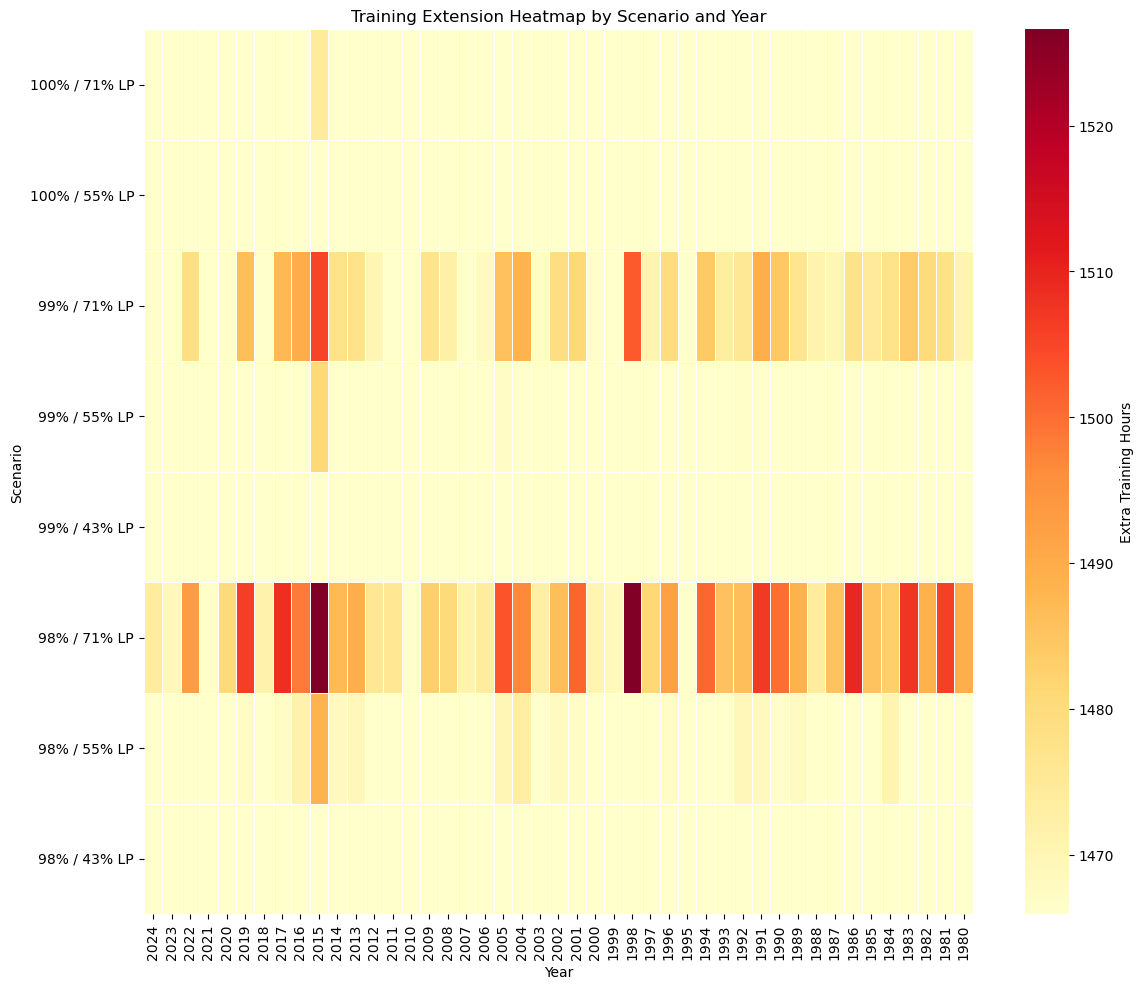

In [20]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === Scenarios with their folder paths ===
scenarios = {
    "100% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_71_percent_inference",
    "100% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_55_percent_inference",
    "99% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_71_percent_inference",
    "99% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_55_percent_inference",
    "99% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_43_percent_inference",
    "98% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_71_percent_inference",
    "98% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_55_percent_inference",
    "98% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_43_percent_inference",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def get_training_extension(power_percent):
    """Calculate training extension factor from available power."""
    power_percent = np.clip(power_percent, 0, 100)
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

# === Store results ===
heatmap_data = pd.DataFrame(index=years, columns=scenarios.keys())

# === Process Each Scenario ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}
    
    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)
            
            # Original available power
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100
            df['Power Available (%)'] = 100 - df['Unmet (%)']
            
            # Adjusted available power: subtract 43%, clip at 0
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - 43, 0, 100)
            
            # Calculate training extension
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(get_training_extension)
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1
            
            # Total extra hours for the year
            total_extra = df['Extra Training Hours'].sum()
            yearly_extension_hours[year] = total_extra
            
            # Optional: save CSV with extension data
            result_path = os.path.join(folder_path, f"training_extension_{year}.csv")
            df.to_csv(result_path, index=False)
            
        except FileNotFoundError:
            print(f"File not found for {year} in scenario {scenario_name}")
            yearly_extension_hours[year] = np.nan
    
    # Add to heatmap data
    heatmap_data[scenario_name] = pd.Series(yearly_extension_hours)

# === Plot heatmap ===
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data.T, cmap="YlOrRd", cbar_kws={'label': 'Extra Training Hours'}, linewidths=0.5)
plt.title("Training Extension Heatmap by Scenario and Year")
plt.xlabel("Year")
plt.ylabel("Scenario")
plt.tight_layout()
plt.show()


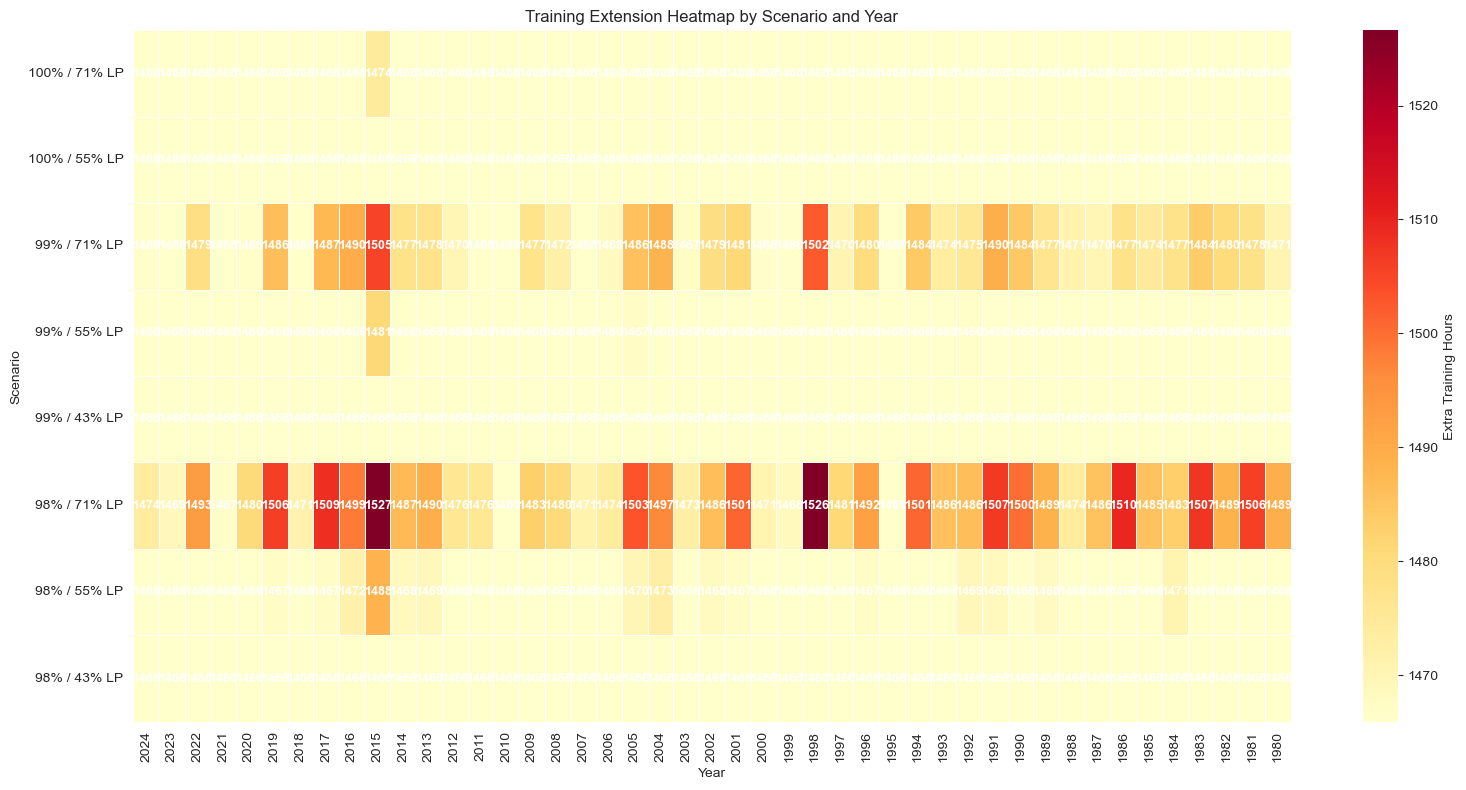

In [22]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === Scenarios with their folder paths ===
scenarios = {
    "100% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_71_percent_inference",
    "100% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_55_percent_inference",
    "99% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_71_percent_inference",
    "99% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_55_percent_inference",
    "99% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_43_percent_inference",
    "98% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_71_percent_inference",
    "98% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_55_percent_inference",
    "98% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_43_percent_inference",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def get_training_extension(power_percent):
    """Calculate training extension factor from available power."""
    power_percent = np.clip(power_percent, 0, 100)
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

# === Store results ===
heatmap_data = pd.DataFrame(index=years, columns=scenarios.keys())

# === Process Each Scenario ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}
    
    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)
            
            # Original available power
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100
            df['Power Available (%)'] = 100 - df['Unmet (%)']
            
            # Adjusted available power: subtract 43%, clip at 0
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - 43, 0, 100)
            
            # Calculate training extension
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(get_training_extension)
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1
            
            # Total extra hours for the year
            total_extra = df['Extra Training Hours'].sum()
            yearly_extension_hours[year] = total_extra
            
        except FileNotFoundError:
            print(f"File not found for {year} in scenario {scenario_name}")
            yearly_extension_hours[year] = np.nan
    
    # Add to heatmap data
    heatmap_data[scenario_name] = pd.Series(yearly_extension_hours)

# === Plot heatmap with exact numbers and dynamic font color ===
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Invert x-axis (years)
heatmap_data = heatmap_data.iloc[::-1]

ax = sns.heatmap(
    heatmap_data.T,
    cmap="YlOrRd",
    annot=heatmap_data.T.round(0).astype(int),
    fmt="d",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize":9, "weight":"bold"}
)

# Dynamic font color: dark on light, light on dark
for text in ax.texts:
    val = float(text.get_text())
    color = "black" if val < heatmap_data.values.max()/2 else "white"
    text.set_color(color)

ax.set_title("Training Extension Heatmap by Scenario and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")
ax.invert_xaxis()  # Years from 2024 -> 1980
plt.tight_layout()
plt.show()


AttributeError: 'Text' object has no attribute 'get_backgroundcolor'

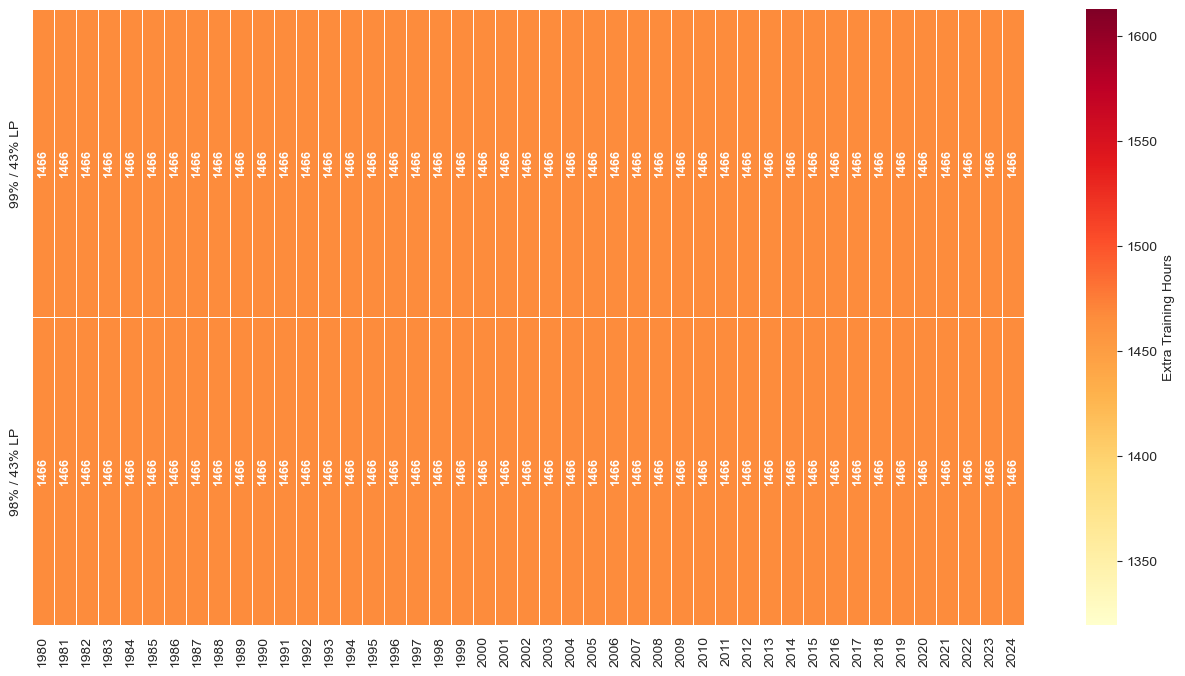

In [24]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === Scenarios with their folder paths ===
scenarios = {
    "99% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_43_percent_inference",
    "98% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_43_percent_inference",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def get_training_extension(power_percent):
    """Calculate training extension factor from available power."""
    power_percent = np.clip(power_percent, 0, 100)
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

# === Store results ===
heatmap_data = pd.DataFrame(index=years, columns=scenarios.keys())

# === Process Each Scenario ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}
    
    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)
            
            # Original available power
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100
            df['Power Available (%)'] = 100 - df['Unmet (%)']
            
            # Adjusted available power: subtract 43%, clip at 0
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - 43, 0, 100)
            
            # Calculate training extension
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(get_training_extension)
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1
            
            # Total extra hours for the year
            total_extra = df['Extra Training Hours'].sum()
            yearly_extension_hours[year] = total_extra
            
        except FileNotFoundError:
            print(f"File not found for {year} in scenario {scenario_name}")
            yearly_extension_hours[year] = np.nan
    
    # Add to heatmap data
    heatmap_data[scenario_name] = pd.Series(yearly_extension_hours)

# === Plot heatmap with exact numbers, vertical font, and dynamic color ===
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Invert x-axis (years)
heatmap_data = heatmap_data.iloc[::-1]

ax = sns.heatmap(
    heatmap_data.T,
    cmap="YlOrRd",
    annot=heatmap_data.T.round(0).astype(int),
    fmt="d",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize": 9, "weight": "bold", "rotation": 90}  # vertical text
)

# Dynamic font color: dark on light, light on dark
for text in ax.texts:
    val = float(text.get_text())
    # get cell background color
    facecolor = text.get_backgroundcolor()
    # or approximate by value relative to max
    color = "black" if val < heatmap_data.values.max()/2 else "white"
    text.set_color(color)

ax.set_title("Training Extension Heatmap by Scenario and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")
ax.invert_xaxis()  # Years from 2024 -> 1980
plt.tight_layout()
plt.show()


AttributeError: 'Text' object has no attribute 'get_backgroundcolor'

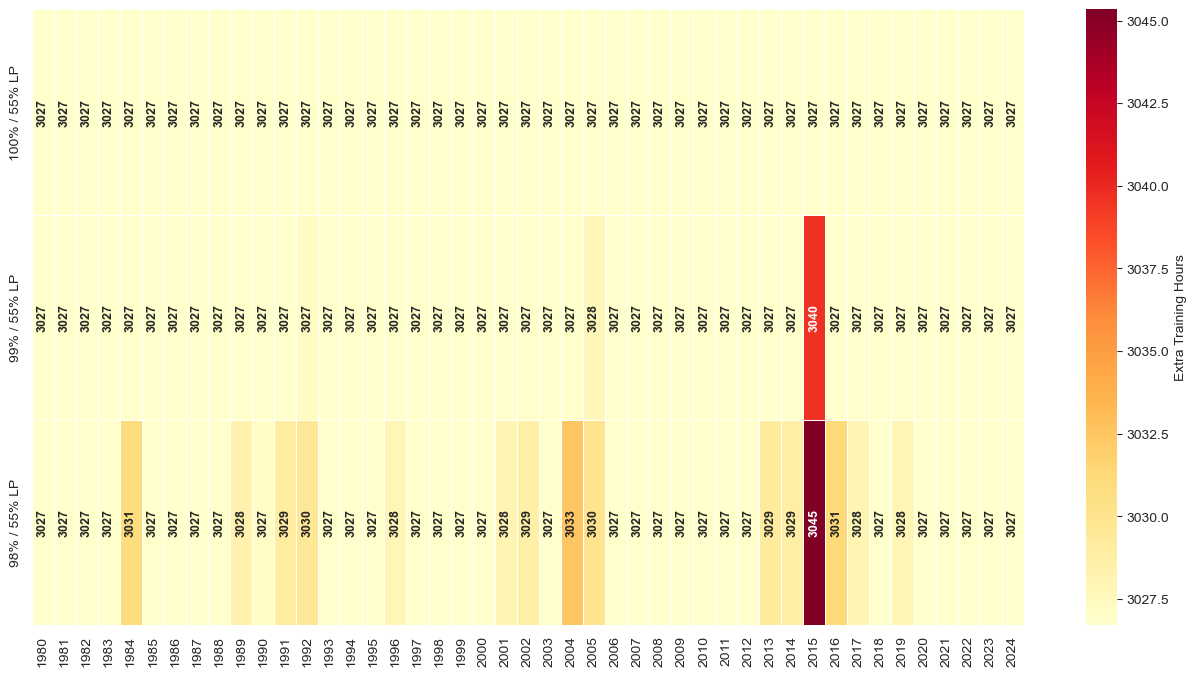

In [3]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === Scenarios with their folder paths ===
scenarios = {
    "100% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_55_percent_inference",
    "99% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_55_percent_inference",
    "98% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_55_percent_inference",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def get_training_extension(power_percent):
    """Calculate training extension factor from available power."""
    power_percent = np.clip(power_percent, 0, 100)
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

# === Store results ===
heatmap_data = pd.DataFrame(index=years, columns=scenarios.keys())

# === Process Each Scenario ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}
    
    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)
            
            # Original available power
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100
            df['Power Available (%)'] = 100 - df['Unmet (%)']
            
            # Adjusted available power: subtract 55%, clip at 0
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - 55, 0, 100)
            
            # Calculate training extension
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(get_training_extension)
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1
            
            # Total extra hours for the year
            total_extra = df['Extra Training Hours'].sum()
            yearly_extension_hours[year] = total_extra
            
        except FileNotFoundError:
            print(f"File not found for {year} in scenario {scenario_name}")
            yearly_extension_hours[year] = np.nan
    
    # Add to heatmap data
    heatmap_data[scenario_name] = pd.Series(yearly_extension_hours)

# === Plot heatmap with exact numbers, vertical font, and dynamic color ===
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Invert x-axis (years)
heatmap_data = heatmap_data.iloc[::-1]

ax = sns.heatmap(
    heatmap_data.T,
    cmap="YlOrRd",
    annot=heatmap_data.T.round(0).astype(int),
    fmt="d",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize": 9, "weight": "bold", "rotation": 90}  # vertical text
)

# Dynamic font color: dark on light, light on dark
for text in ax.texts:
    val = float(text.get_text())
    # get cell background color
    facecolor = text.get_backgroundcolor()
    # or approximate by value relative to max
    color = "black" if val < heatmap_data.values.max()/2 else "white"
    text.set_color(color)

ax.set_title("Training Extension Heatmap by Scenario and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")
ax.invert_xaxis()  # Years from 2024 -> 1980
plt.tight_layout()
plt.show()


AttributeError: 'Text' object has no attribute 'get_backgroundcolor'

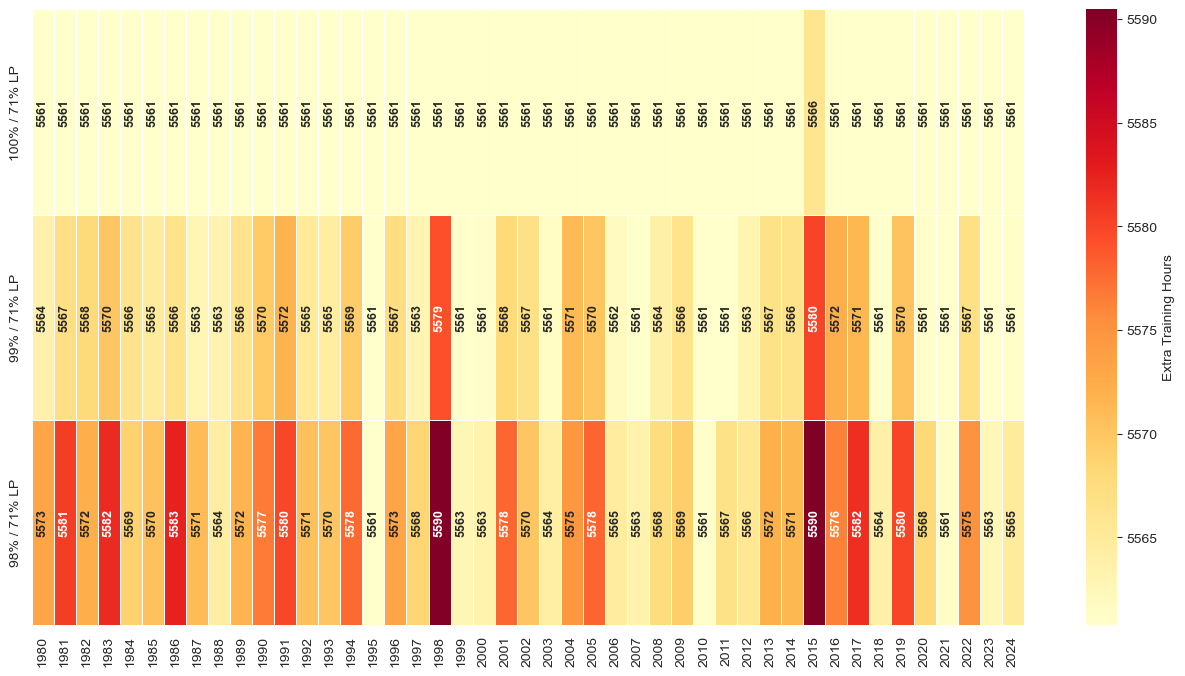

In [5]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === Scenarios with their folder paths ===
scenarios = {
    "100% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_71_percent_inference",
    "99% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_71_percent_inference",
    "98% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_71_percent_inference",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def get_training_extension(power_percent):
    """Calculate training extension factor from available power."""
    power_percent = np.clip(power_percent, 0, 100)
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

# === Store results ===
heatmap_data = pd.DataFrame(index=years, columns=scenarios.keys())

# === Process Each Scenario ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}
    
    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)
            
            # Original available power
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100
            df['Power Available (%)'] = 100 - df['Unmet (%)']
            
            # Adjusted available power: subtract 71%, clip at 0
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - 71, 0, 100)
            
            # Calculate training extension
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(get_training_extension)
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1
            
            # Total extra hours for the year
            total_extra = df['Extra Training Hours'].sum()
            yearly_extension_hours[year] = total_extra
            
        except FileNotFoundError:
            print(f"File not found for {year} in scenario {scenario_name}")
            yearly_extension_hours[year] = np.nan
    
    # Add to heatmap data
    heatmap_data[scenario_name] = pd.Series(yearly_extension_hours)

# === Plot heatmap with exact numbers, vertical font, and dynamic color ===
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Invert x-axis (years)
heatmap_data = heatmap_data.iloc[::-1]

ax = sns.heatmap(
    heatmap_data.T,
    cmap="YlOrRd",
    annot=heatmap_data.T.round(0).astype(int),
    fmt="d",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize": 9, "weight": "bold", "rotation": 90}  # vertical text
)

# Dynamic font color: dark on light, light on dark
for text in ax.texts:
    val = float(text.get_text())
    # get cell background color
    facecolor = text.get_backgroundcolor()
    # or approximate by value relative to max
    color = "black" if val < heatmap_data.values.max()/2 else "white"
    text.set_color(color)

ax.set_title("Training Extension Heatmap by Scenario and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")
ax.invert_xaxis()  # Years from 2024 -> 1980
plt.tight_layout()
plt.show()


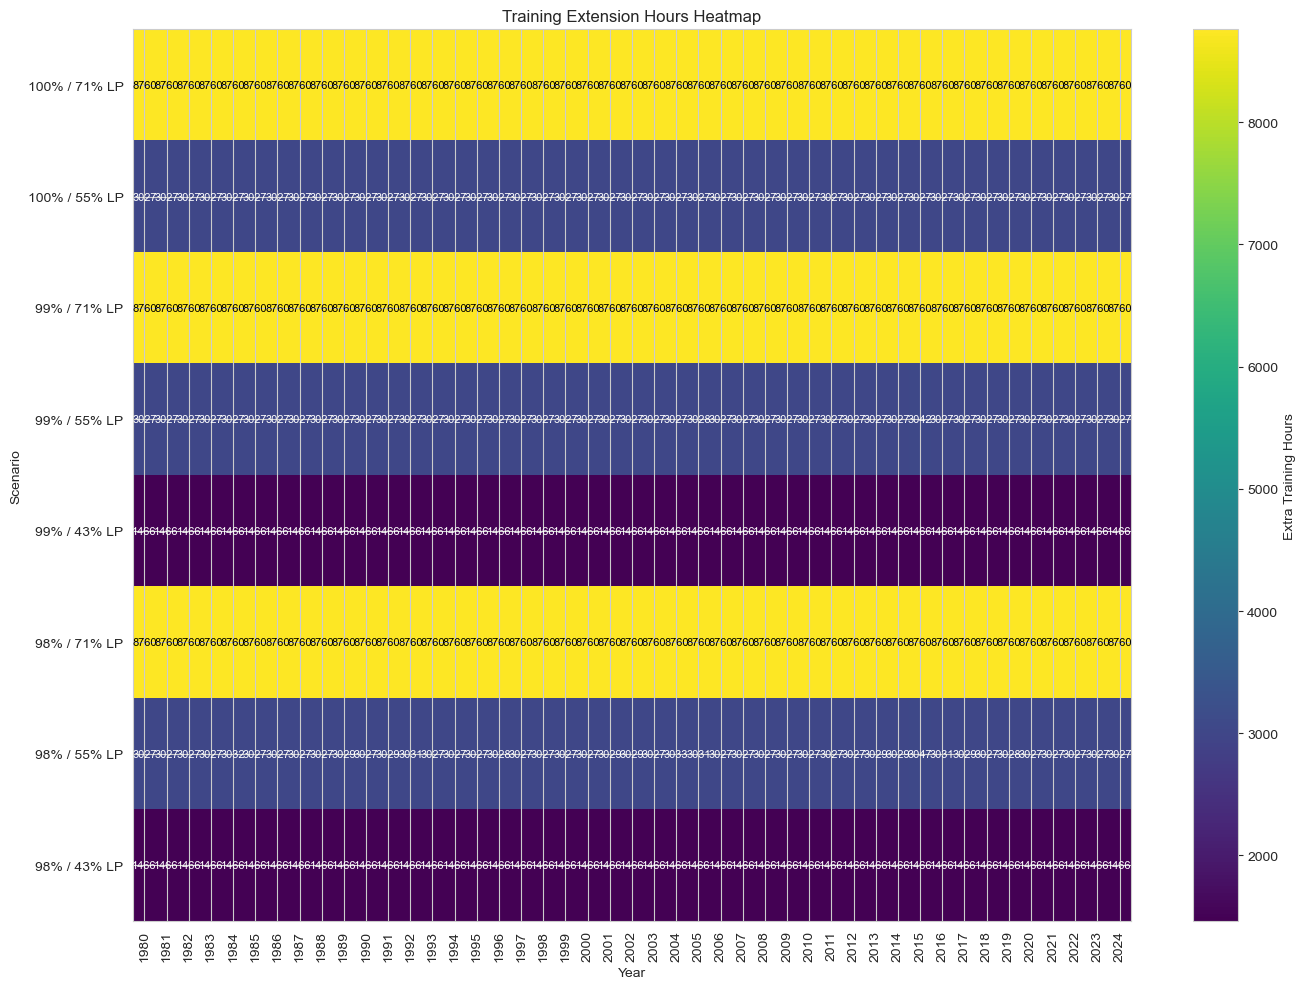

In [28]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# === Scenarios ===
scenarios = {
    "100% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_71_percent_inference",
    "100% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_55_percent_inference",
    "99% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_71_percent_inference",
    "99% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_55_percent_inference",
    "99% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_43_percent_inference",
    "98% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_71_percent_inference",
    "98% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_55_percent_inference",
    "98% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_43_percent_inference",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250

interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def get_training_extension(power_percent):
    power_percent = np.clip(power_percent, 0, 100)  # Keep between 0 and 100%
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

# === Storage for heatmap ===
heatmap_data = pd.DataFrame(index=[str(y) for y in years], columns=scenarios.keys())

# === Process each scenario ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}

    # Parse the LP number to determine subtraction
    try:
        lp_str = scenario_name.split('/')[-1].split('LP')[0].strip()  # e.g., '71%'
        subtract_percent = int(lp_str.replace('%', ''))
    except:
        subtract_percent = 0  # default 0 if parsing fails

    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)

            # Calculate original available power
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100
            df['Power Available (%)'] = 100 - df['Unmet (%)']

            # Adjust for scenario-specific LP subtraction
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - subtract_percent, 0, 100)

            # Training extension
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(
                lambda p: 2.0 if p < (100 / 250 * 100) else get_training_extension(p)
            )
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1

            # Save CSV
            columns_to_save = [
                'Hour', 'Load (kW)', 'Unmet (kW)', 'Unmet (%)',
                'Power Available (%)', 'Power Available Adjusted (%)',
                'Training Time Extension (×)', 'Extra Training Hours'
            ]
            save_path = os.path.join(folder_path, f"training_extension_{year}.csv")
            df[columns_to_save].to_csv(save_path, index=False)

            # Sum extra training hours
            total_extra = df['Extra Training Hours'].sum()
            yearly_extension_hours[year] = total_extra

        except FileNotFoundError:
            yearly_extension_hours[year] = None

    # Fill heatmap dataframe
    for year in years:
        heatmap_data.at[str(year), scenario_name] = yearly_extension_hours.get(year, np.nan)

# Convert to numeric
heatmap_data = heatmap_data.astype(float)

# === Plot Heatmap ===
plt.figure(figsize=(14, 10))
cmap = plt.cm.viridis
im = plt.imshow(heatmap_data.T, aspect='auto', cmap=cmap)

plt.colorbar(im, label='Extra Training Hours')
plt.xticks(ticks=np.arange(len(years)), labels=years, rotation=90)
plt.gca().invert_xaxis()  # invert x-axis

plt.yticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns, rotation=0)

# Annotate each cell
for i in range(len(heatmap_data.columns)):
    for j in range(len(heatmap_data.index)):
        val = heatmap_data.iloc[j, i]
        color = 'white' if im.cmap(im.norm(val))[:3] < (0.5, 0.5, 0.5) else 'black'
        plt.text(j, i, f"{val:.0f}", ha='center', va='center', color=color, fontsize=8)

plt.title("Training Extension Hours Heatmap")
plt.xlabel("Year")
plt.ylabel("Scenario")
plt.tight_layout()
plt.show()


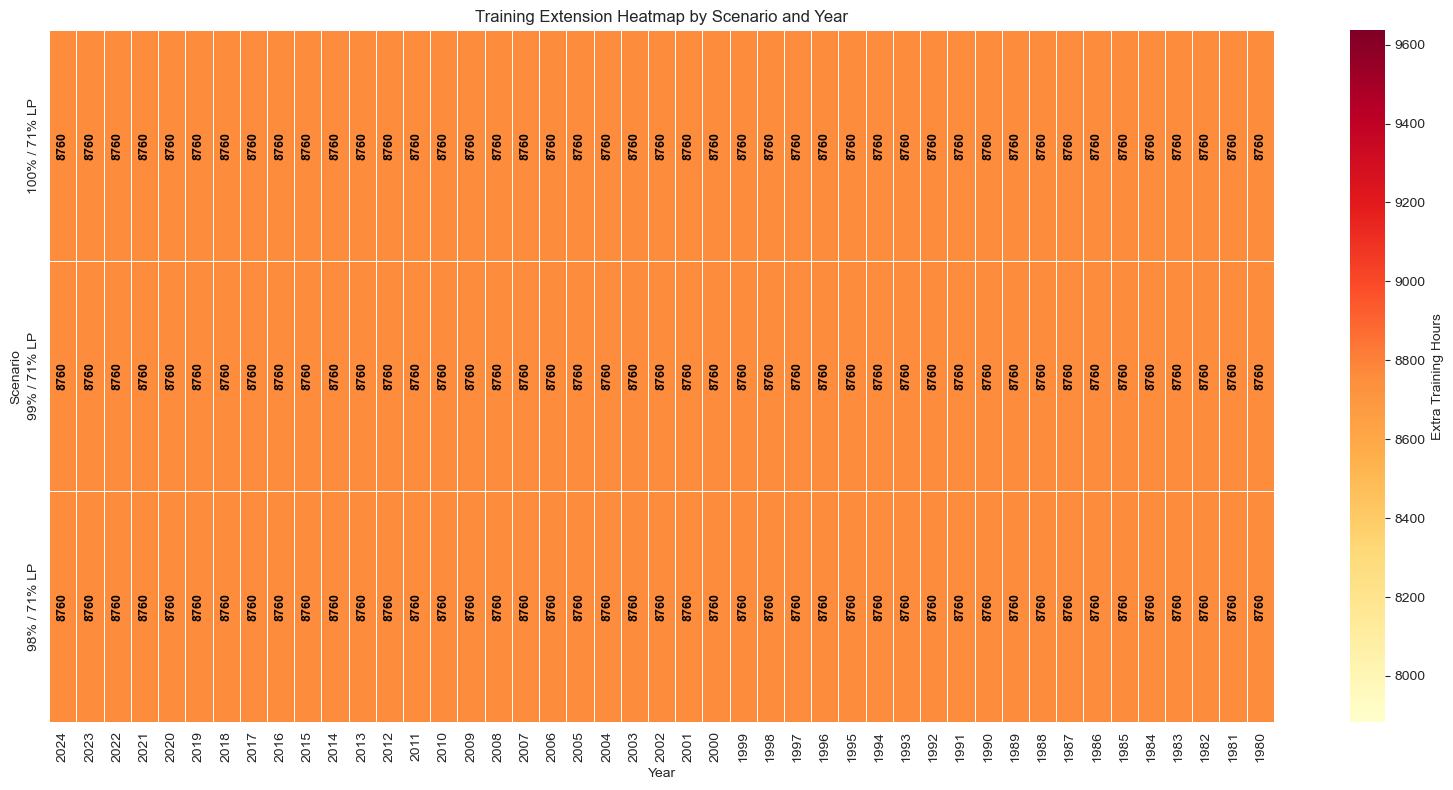

In [7]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === Scenarios with their folder paths ===
scenarios = {
    "100% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_71_percent_inference",
    "99% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_71_percent_inference",
    "98% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_71_percent_inference",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]  # 40,000
extension_factors = training_times / baseline_time  # from 1.0 up to 2.0
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def ext_factor_from_percent(pct_available: float) -> float:
    """
    Return training-time extension factor (×) from available power percent.
    IMPORTANT: If available power < 40%, force 2× (=> 1 extra hour per hour).
    """
    p = float(np.clip(pct_available, 0, 100))
    if p < 40.0:
        return 2.0
    missing_fraction = 1 - (p / 100.0)
    return float(interpolator(missing_fraction))

# === Store results ===
heatmap_data = pd.DataFrame(index=years, columns=scenarios.keys(), dtype=float)

# === Process Each Scenario ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}

    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)

            # Original available power (%)
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100.0
            df['Power Available (%)'] = 100.0 - df['Unmet (%)']

            # Adjusted available power: subtract 71%, clip to [0, 100]
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - 71.0, 0.0, 100.0)

            # Extension factor with the <40% => 2× rule
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(ext_factor_from_percent)

            # Extra hours per hour = (factor - 1)
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1.0

            # Sum across ALL rows (hours)
            total_extra = float(df['Extra Training Hours'].sum())
            yearly_extension_hours[year] = total_extra

            # (Optional) write per-year CSV with adjusted columns for inspection
            out_cols = [
                'Hour','Load (kW)','Unmet (kW)','Unmet (%)',
                'Power Available (%)','Power Available Adjusted (%)',
                'Training Time Extension (×)','Extra Training Hours'
            ]
            out_cols = [c for c in out_cols if c in df.columns]
            df[out_cols].to_csv(os.path.join(folder_path, f"training_extension_{year}.csv"), index=False)

        except FileNotFoundError:
            print(f"File not found for {year} in scenario {scenario_name}")
            yearly_extension_hours[year] = np.nan

    heatmap_data[scenario_name] = pd.Series(yearly_extension_hours)

# === Plot heatmap with exact numbers, vertical font, and true dynamic contrast ===
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Reverse years left→right (2024 → 1980)
heatmap_plot = heatmap_data.iloc[::-1]  # rows = years descending

ax = sns.heatmap(
    heatmap_plot.T,
    cmap="YlOrRd",
    annot=heatmap_plot.T.round(0).astype("Int64"),
    fmt="d",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize": 9, "weight": "bold", "rotation": 90}
)

# Invert x-axis so 2024 is at left
ax.invert_xaxis()
ax.set_title("Training Extension Heatmap by Scenario and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")

# Improve annotation contrast using actual colormap luminance
cmap = plt.get_cmap("YlOrRd")
vmin = np.nanmin(heatmap_plot.values)
vmax = np.nanmax(heatmap_plot.values)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

for text in ax.texts:
    try:
        val = float(text.get_text())
    except ValueError:
        continue
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299*r + 0.587*g + 0.114*b
    text.set_color("black" if luminance > 0.60 else "white")

plt.tight_layout()
plt.show()


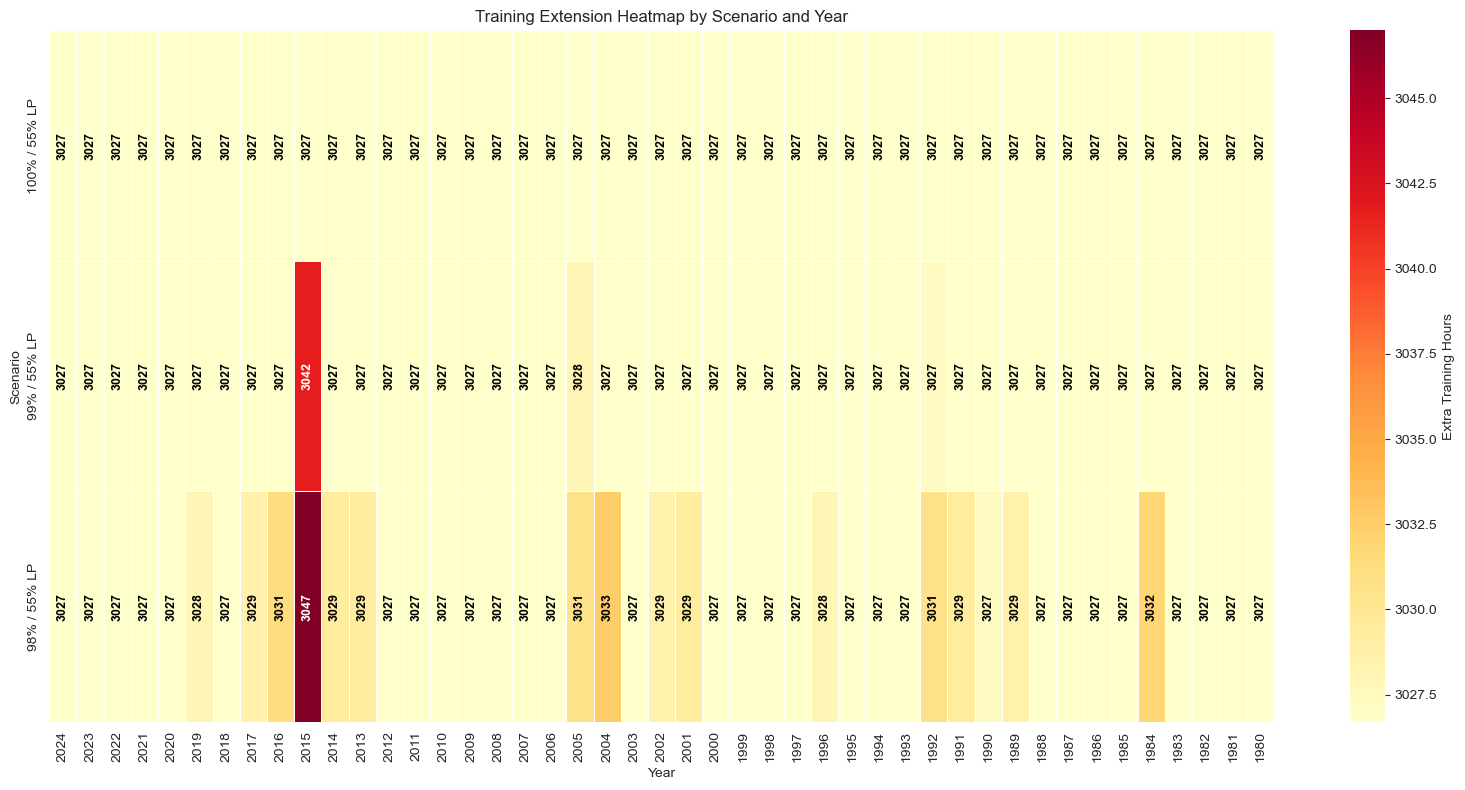

In [11]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === Scenarios with their folder paths ===
scenarios = {
    "100% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_55_percent_inference",
    "99% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_55_percent_inference",
    "98% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_55_percent_inference",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]  # 40,000
extension_factors = training_times / baseline_time  # from 1.0 up to 2.0
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def ext_factor_from_percent(pct_available: float) -> float:
    """
    Return training-time extension factor (×) from available power percent.
    IMPORTANT: If available power < 40%, force 2× (=> 1 extra hour per hour).
    """
    p = float(np.clip(pct_available, 0, 100))
    if p < 40.0:
        return 2.0
    missing_fraction = 1 - (p / 100.0)
    return float(interpolator(missing_fraction))

# === Store results ===
heatmap_data = pd.DataFrame(index=years, columns=scenarios.keys(), dtype=float)

# === Process Each Scenario ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}

    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)

            # Original available power (%)
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100.0
            df['Power Available (%)'] = 100.0 - df['Unmet (%)']

            # Adjusted available power: subtract 55%, clip to [0, 100]
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - 55.0, 0.0, 100.0)

            # Extension factor with the <40% => 2× rule
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(ext_factor_from_percent)

            # Extra hours per hour = (factor - 1)
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1.0

            # Sum across ALL rows (hours)
            total_extra = float(df['Extra Training Hours'].sum())
            yearly_extension_hours[year] = total_extra

            # (Optional) write per-year CSV with adjusted columns for inspection
            out_cols = [
                'Hour','Load (kW)','Unmet (kW)','Unmet (%)',
                'Power Available (%)','Power Available Adjusted (%)',
                'Training Time Extension (×)','Extra Training Hours'
            ]
            out_cols = [c for c in out_cols if c in df.columns]
            df[out_cols].to_csv(os.path.join(folder_path, f"training_extension_{year}.csv"), index=False)

        except FileNotFoundError:
            print(f"File not found for {year} in scenario {scenario_name}")
            yearly_extension_hours[year] = np.nan

    heatmap_data[scenario_name] = pd.Series(yearly_extension_hours)

# === Plot heatmap with exact numbers, vertical font, and true dynamic contrast ===
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Reverse years left→right (2024 → 1980)
heatmap_plot = heatmap_data.iloc[::-1]  # rows = years descending

ax = sns.heatmap(
    heatmap_plot.T,
    cmap="YlOrRd",
    annot=heatmap_plot.T.round(0).astype("Int64"),
    fmt="d",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize": 9, "weight": "bold", "rotation": 90}
)

# Invert x-axis so 2024 is at left
ax.invert_xaxis()
ax.set_title("Training Extension Heatmap by Scenario and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")

# Improve annotation contrast using actual colormap luminance
cmap = plt.get_cmap("YlOrRd")
vmin = np.nanmin(heatmap_plot.values)
vmax = np.nanmax(heatmap_plot.values)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

for text in ax.texts:
    try:
        val = float(text.get_text())
    except ValueError:
        continue
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299*r + 0.587*g + 0.114*b
    text.set_color("black" if luminance > 0.60 else "white")

plt.tight_layout()
plt.show()


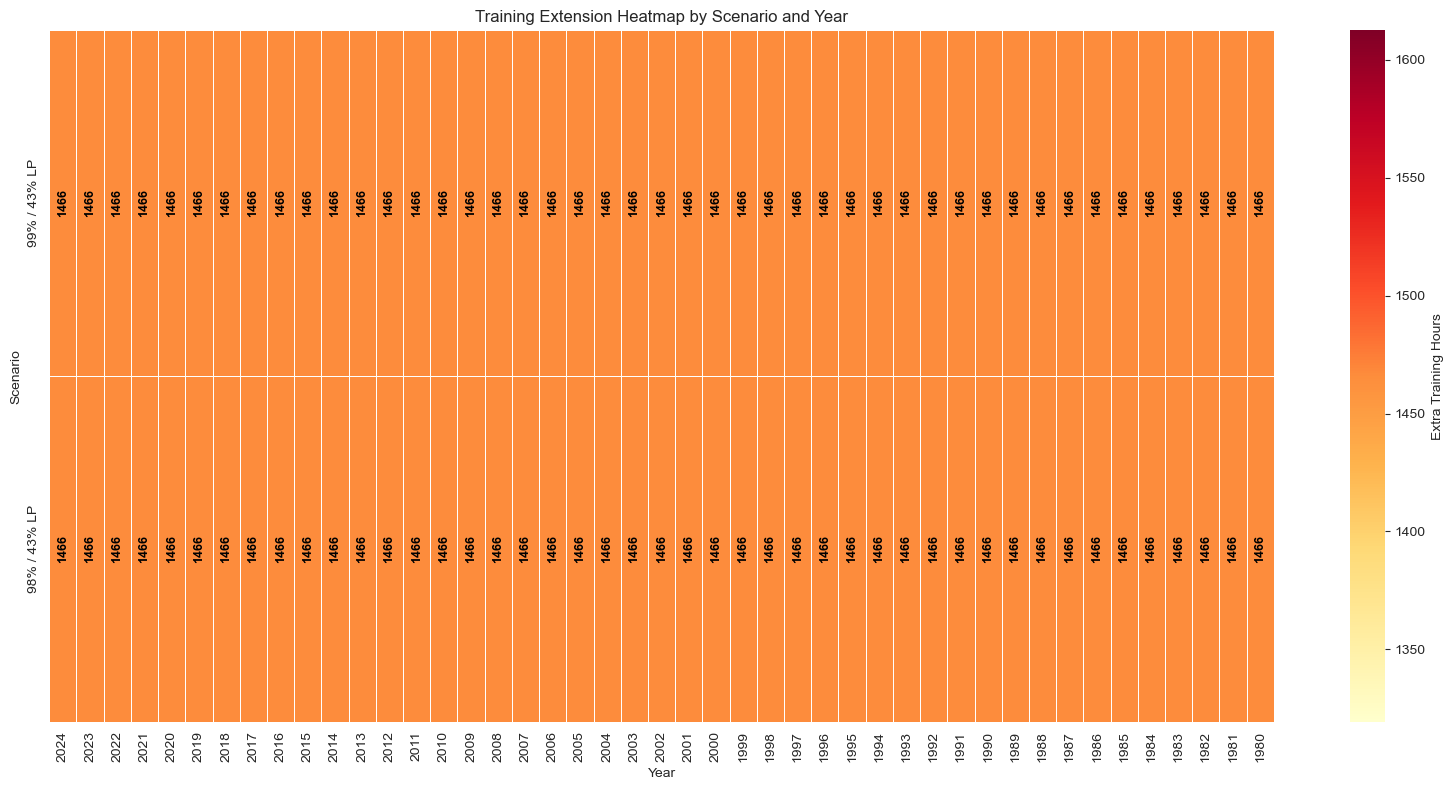

In [1]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === Scenarios with their folder paths ===
scenarios = {
    "99% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_43_percent_inference",
    "98% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_43_percent_inference",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]  # 40,000
extension_factors = training_times / baseline_time  # from 1.0 up to 2.0
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def ext_factor_from_percent(pct_available: float) -> float:
    """
    Return training-time extension factor (×) from available power percent.
    IMPORTANT: If available power < 40%, force 2× (=> 1 extra hour per hour).
    """
    p = float(np.clip(pct_available, 0, 100))
    if p < 40.0:
        return 2.0
    missing_fraction = 1 - (p / 100.0)
    return float(interpolator(missing_fraction))

# === Store results ===
heatmap_data = pd.DataFrame(index=years, columns=scenarios.keys(), dtype=float)

# === Process Each Scenario ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}

    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)

            # Original available power (%)
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100.0
            df['Power Available (%)'] = 100.0 - df['Unmet (%)']

            # Adjusted available power: subtract 43%, clip to [0, 100]
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - 43.0, 0.0, 100.0)

            # Extension factor with the <40% => 2× rule
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(ext_factor_from_percent)

            # Extra hours per hour = (factor - 1)
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1.0

            # Sum across ALL rows (hours)
            total_extra = float(df['Extra Training Hours'].sum())
            yearly_extension_hours[year] = total_extra

            # (Optional) write per-year CSV with adjusted columns for inspection
            out_cols = [
                'Hour','Load (kW)','Unmet (kW)','Unmet (%)',
                'Power Available (%)','Power Available Adjusted (%)',
                'Training Time Extension (×)','Extra Training Hours'
            ]
            out_cols = [c for c in out_cols if c in df.columns]
            df[out_cols].to_csv(os.path.join(folder_path, f"training_extension_{year}.csv"), index=False)

        except FileNotFoundError:
            print(f"File not found for {year} in scenario {scenario_name}")
            yearly_extension_hours[year] = np.nan

    heatmap_data[scenario_name] = pd.Series(yearly_extension_hours)

# === Plot heatmap with exact numbers, vertical font, and true dynamic contrast ===
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Reverse years left→right (2024 → 1980)
heatmap_plot = heatmap_data.iloc[::-1]  # rows = years descending

ax = sns.heatmap(
    heatmap_plot.T,
    cmap="YlOrRd",
    annot=heatmap_plot.T.round(0).astype("Int64"),
    fmt="d",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize": 9, "weight": "bold", "rotation": 90}
)

# Invert x-axis so 2024 is at left
ax.invert_xaxis()
ax.set_title("Training Extension Heatmap by Scenario and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")

# Improve annotation contrast using actual colormap luminance
cmap = plt.get_cmap("YlOrRd")
vmin = np.nanmin(heatmap_plot.values)
vmax = np.nanmax(heatmap_plot.values)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

for text in ax.texts:
    try:
        val = float(text.get_text())
    except ValueError:
        continue
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299*r + 0.587*g + 0.114*b
    text.set_color("black" if luminance > 0.60 else "white")

plt.tight_layout()
plt.show()


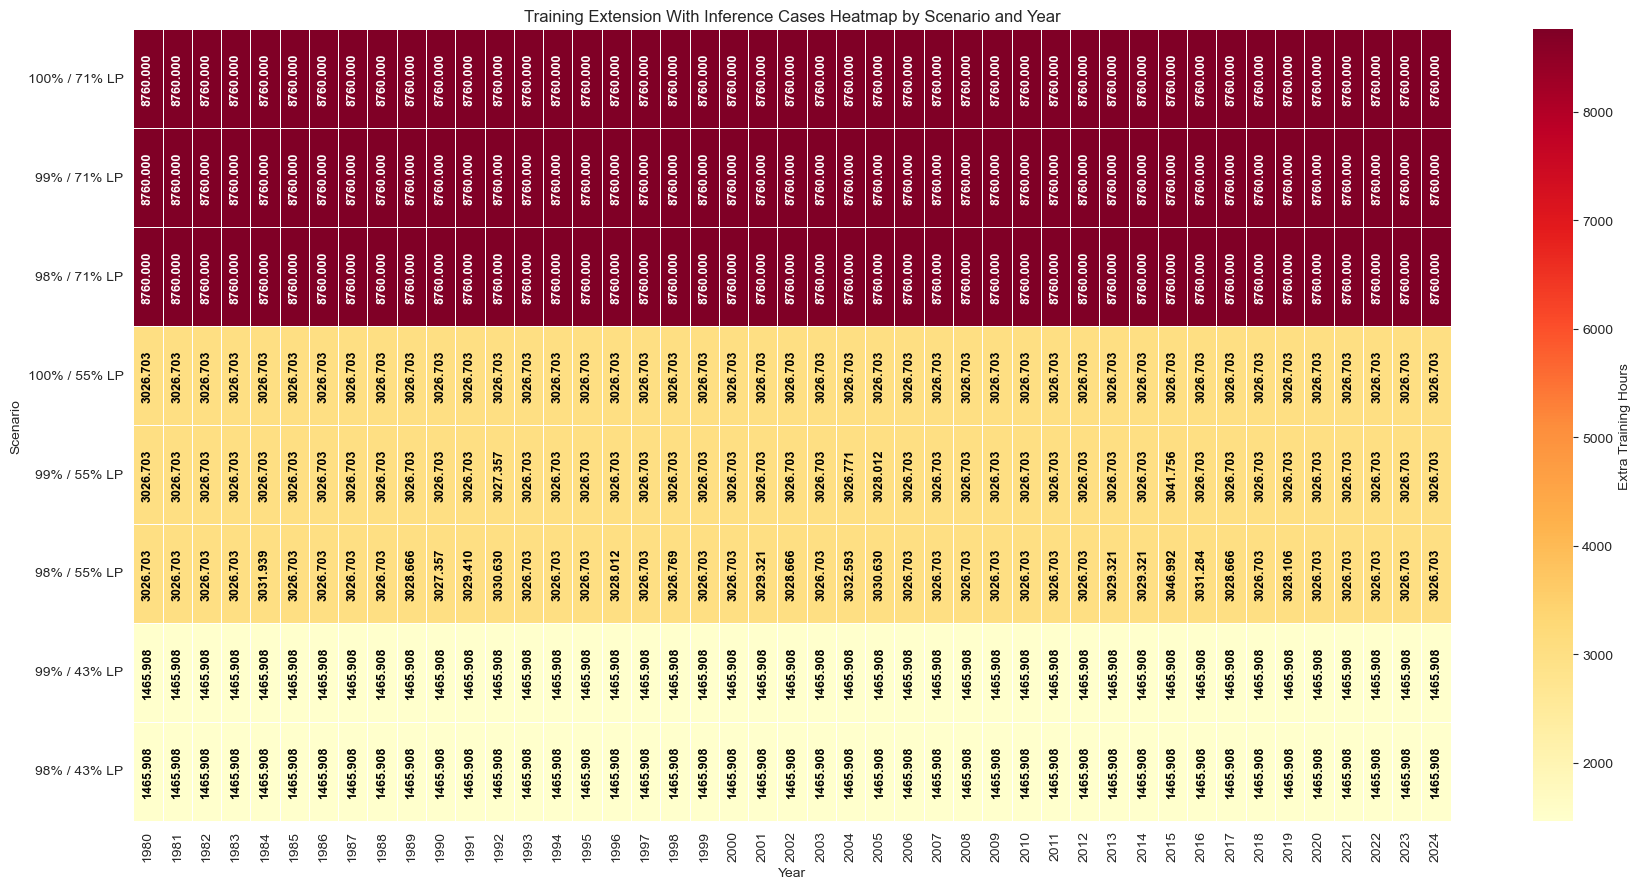

In [1]:
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === All scenarios in one dict ===
scenarios = {
    # 71% LP group
    "100% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_71_percent_inference",
    "99% / 71% LP":  r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_71_percent_inference",
    "98% / 71% LP":  r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_71_percent_inference",
    # 55% LP group
    "100% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_55_percent_inference",
    "99% / 55% LP":  r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_55_percent_inference",
    "98% / 55% LP":  r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_55_percent_inference",
    # 43% LP group
    "99% / 43% LP":  r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_43_percent_inference",
    "98% / 43% LP":  r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_43_percent_inference",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]                 # 40,000
extension_factors = training_times / baseline_time  # 1.0 .. 2.0
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def ext_factor_from_percent(pct_available: float) -> float:
    """
    Training-time extension factor (×) from available power percent.
    If available power < 40%, force 2× (=> 1 extra hour per hour).
    """
    p = float(np.clip(pct_available, 0, 100))
    if p < 40.0:
        return 2.0
    missing_fraction = 1 - (p / 100.0)
    return float(interpolator(missing_fraction))

# === Results storage for the heatmap ===
heatmap_data = pd.DataFrame(index=years, columns=scenarios.keys(), dtype=float)

# === Process all scenarios together ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}

    # Parse LP from scenario string (e.g., "... / 71% LP" -> 71)
    try:
        lp_str = scenario_name.split('/')[-1].split('LP')[0].strip().replace('%', '')
        subtract_percent = float(lp_str)
    except Exception:
        subtract_percent = 0.0  # fallback

    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)

            # Original available power (%)
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100.0
            df['Power Available (%)'] = 100.0 - df['Unmet (%)']

            # Scenario-specific LP subtraction, clip to [0, 100]
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - subtract_percent, 0.0, 100.0)

            # Extension factor with the <40% => 2× rule
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(ext_factor_from_percent)

            # Extra hours per hour = factor - 1
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1.0

            # Sum across ALL hours; store with 3 decimals
            total_extra = float(df['Extra Training Hours'].sum())
            yearly_extension_hours[year] = round(total_extra, 3)

            # (Optional) save per-year outputs with 3-decimal rounding for inspection
            out_cols = [
                'Hour','Load (kW)','Unmet (kW)','Unmet (%)',
                'Power Available (%)','Power Available Adjusted (%)',
                'Training Time Extension (×)','Extra Training Hours'
            ]
            present_cols = [c for c in out_cols if c in df.columns]
            if present_cols:
                df_save = df[present_cols].copy()
                for c in ['Unmet (%)','Power Available (%)','Power Available Adjusted (%)',
                          'Training Time Extension (×)','Extra Training Hours']:
                    if c in df_save.columns:
                        df_save[c] = df_save[c].astype(float).round(3)
                df_save.to_csv(os.path.join(folder_path, f"training_extension_{year}.csv"), index=False)

        except FileNotFoundError:
            print(f"File not found for {year} in scenario {scenario_name}")
            yearly_extension_hours[year] = np.nan

    heatmap_data[scenario_name] = pd.Series(yearly_extension_hours)

# === Plot a single heatmap (3-decimal annotations), vertical font, inverted x-axis, auto-contrast ===
plt.figure(figsize=(18, 9))
sns.set_style("whitegrid")

# Years left→right as 2024 → 1980
heatmap_plot = heatmap_data.iloc[::-1]  # reverse row order so columns go 2024..1980 left->right

ax = sns.heatmap(
    heatmap_plot.T,                     # scenarios as rows
    cmap="YlOrRd",
    annot=heatmap_plot.T.round(3),      # show 3 decimals
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize": 9, "weight": "bold", "rotation": 90}
)

ax.set_title("Training Extension With Inference Cases Memphis Heatmap by Scenario and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")

# Improve annotation contrast using actual colormap luminance
cmap = plt.get_cmap("YlOrRd")
vmin = np.nanmin(heatmap_plot.values)
vmax = np.nanmax(heatmap_plot.values)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

for text in ax.texts:
    try:
        val = float(text.get_text())
    except ValueError:
        continue
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299*r + 0.587*g + 0.114*b
    text.set_color("black" if luminance > 0.60 else "white")

plt.tight_layout()
plt.show()


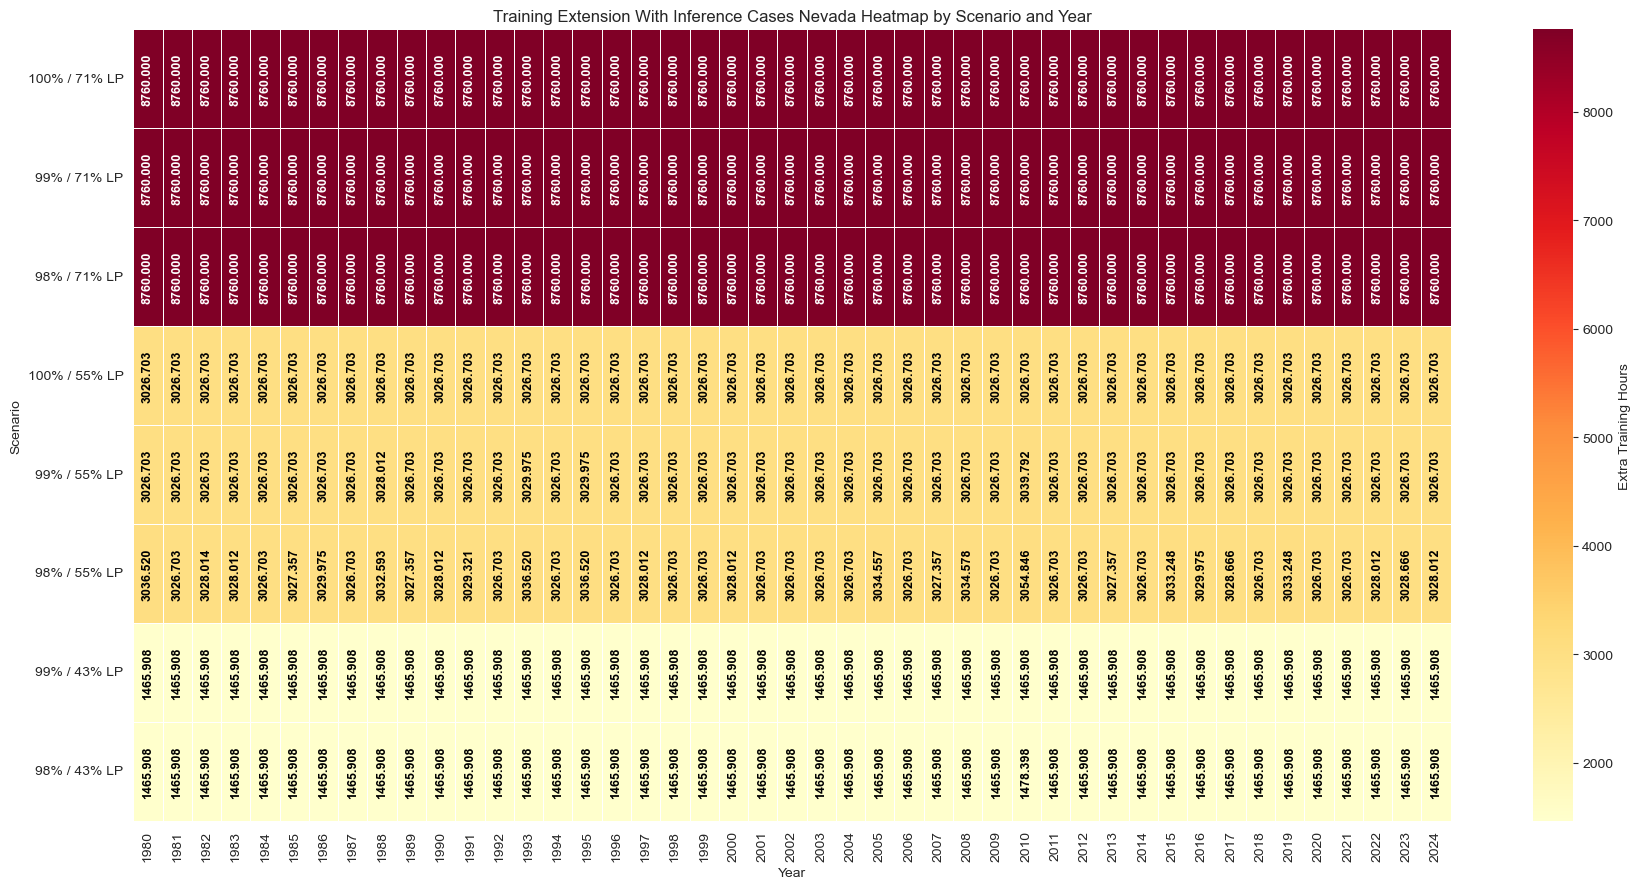

In [17]:

import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === All scenarios in one dict ===
scenarios = {
    # 71% LP group
    "100% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_71_percent_inference_Nevada2023",
    "99% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_71_percent_inference_Nevada2023",
    "98% / 71% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_71_percent_inference_Nevada2023",
    # 55% LP group
    "100% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_100_percent_met_55_percent_inference_Nevada2023",
    "99% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_55_percent_inference_Nevada2023",
    "98% / 55% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_55_percent_inference_Nevada2023",
    # 43% LP group
    "99% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_99_percent_met_43_percent_inference_Nevada2023",  
    "98% / 43% LP": r"C:\Users\Abdullah\dispatch_outputs_98_percent_met_43_percent_inference_Nevada2023",
}

years = list(range(2024, 1979, -1))

# === Training Extension Interpolation Setup ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100, 50, 0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000, 70000, 80000])
baseline_time = training_times[0]                 # 40,000
extension_factors = training_times / baseline_time  # 1.0 .. 2.0
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

def ext_factor_from_percent(pct_available: float) -> float:
    """
    Training-time extension factor (×) from available power percent.
    If available power < 40%, force 2× (=> 1 extra hour per hour).
    """
    p = float(np.clip(pct_available, 0, 100))
    if p < 40.0:
        return 2.0
    missing_fraction = 1 - (p / 100.0)
    return float(interpolator(missing_fraction))

# === Results storage for the heatmap ===
heatmap_data = pd.DataFrame(index=years, columns=scenarios.keys(), dtype=float)

# === Process all scenarios together ===
for scenario_name, folder_path in scenarios.items():
    yearly_extension_hours = {}

    # Parse LP from scenario string (e.g., "... / 71% LP" -> 71)
    try:
        lp_str = scenario_name.split('/')[-1].split('LP')[0].strip().replace('%', '')
        subtract_percent = float(lp_str)
    except Exception:
        subtract_percent = 0.0  # fallback

    for year in years:
        file_path = os.path.join(folder_path, f"dispatch_data_{year}.csv")
        try:
            df = pd.read_csv(file_path)

            # Original available power (%)
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100.0
            df['Power Available (%)'] = 100.0 - df['Unmet (%)']

            # Scenario-specific LP subtraction, clip to [0, 100]
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - subtract_percent, 0.0, 100.0)

            # Extension factor with the <40% => 2× rule
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(ext_factor_from_percent)

            # Extra hours per hour = factor - 1
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1.0

            # Sum across ALL hours; store with 3 decimals
            total_extra = float(df['Extra Training Hours'].sum())
            yearly_extension_hours[year] = round(total_extra, 3)

            # (Optional) save per-year outputs with 3-decimal rounding for inspection
            out_cols = [
                'Hour','Load (kW)','Unmet (kW)','Unmet (%)',
                'Power Available (%)','Power Available Adjusted (%)',
                'Training Time Extension (×)','Extra Training Hours'
            ]
            present_cols = [c for c in out_cols if c in df.columns]
            if present_cols:
                df_save = df[present_cols].copy()
                for c in ['Unmet (%)','Power Available (%)','Power Available Adjusted (%)',
                          'Training Time Extension (×)','Extra Training Hours']:
                    if c in df_save.columns:
                        df_save[c] = df_save[c].astype(float).round(3)
                df_save.to_csv(os.path.join(folder_path, f"training_extension_{year}.csv"), index=False)

        except FileNotFoundError:
            print(f"File not found for {year} in scenario {scenario_name}")
            yearly_extension_hours[year] = np.nan

    heatmap_data[scenario_name] = pd.Series(yearly_extension_hours)

# === Plot a single heatmap (3-decimal annotations), vertical font, inverted x-axis, auto-contrast ===
plt.figure(figsize=(18, 9))
sns.set_style("whitegrid")

# Years left→right as 2024 → 1980
heatmap_plot = heatmap_data.iloc[::-1]  # reverse row order so columns go 2024..1980 left->right

ax = sns.heatmap(
    heatmap_plot.T,                     # scenarios as rows
    cmap="YlOrRd",
    annot=heatmap_plot.T.round(3),      # show 3 decimals
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize": 9, "weight": "bold", "rotation": 90}
)

ax.set_title("Training Extension With Inference Cases Nevada Heatmap by Scenario and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")

# Improve annotation contrast using actual colormap luminance
cmap = plt.get_cmap("YlOrRd")
vmin = np.nanmin(heatmap_plot.values)
vmax = np.nanmax(heatmap_plot.values)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

for text in ax.texts:
    try:
        val = float(text.get_text())
    except ValueError:
        continue
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299*r + 0.587*g + 0.114*b
    text.set_color("black" if luminance > 0.60 else "white")

plt.tight_layout()
plt.show()


C:\Users\Abdullah\AppData\Local\Temp\ipykernel_47876\1243536391.py:166: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abdullah\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


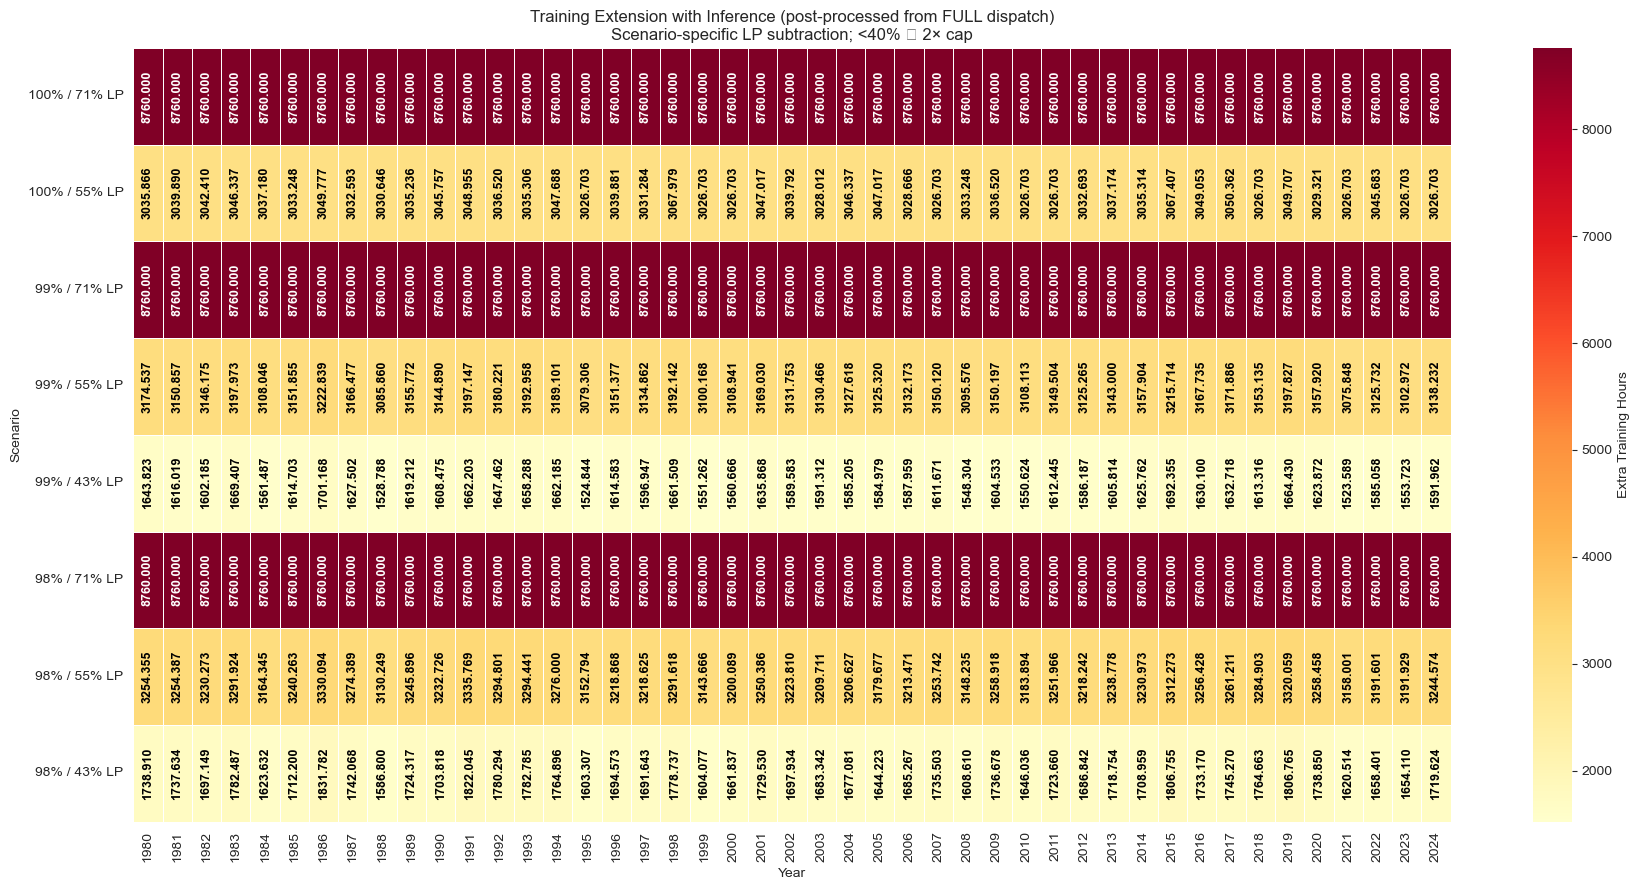

In [21]:
import os
import re
import glob
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === Full-baseline dispatch folders by RDML ===
base_dispatch = {
    100: r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc",
    99:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metLoadCostCurtailment",
    98:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_98metLoadCostCurtailment",
}

# === Scenarios to compute (label ⇒ (RDML, LP)) ===
# You can add/remove scenarios by editing this dict.
scenarios = {
    "100% / 71% LP": (100, 71),
    "100% / 55% LP": (100, 55),
    "99% / 71% LP":  (99, 71),
    "99% / 55% LP":  (99, 55),
    "99% / 43% LP":  (99, 43),
    "98% / 71% LP":  (98, 71),
    "98% / 55% LP":  (98, 55),
    "98% / 43% LP":  (98, 43),
}

# === Training extension interpolation (1.0..2.0×) ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100,  50,   0])
training_times = np.array([40000,42000,42500,45000,46000,50000,58000,70000,80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(
    power_missing_fraction, extension_factors,
    kind='cubic', fill_value='extrapolate'
)

def ext_factor_from_percent(pct_available: float) -> float:
    """
    Training-time extension factor (×) from available power percent.
    If available power < 40%, force 2× (=> 1 extra hour per hour).
    """
    p = float(np.clip(pct_available, 0, 100))
    if p < 40.0:
        return 2.0
    missing_fraction = 1 - (p / 100.0)
    return float(interpolator(missing_fraction))

def find_year_files(folder: str) -> dict[int, str]:
    """Scan folder for dispatch_data_*.csv and return {year -> path}."""
    if not os.path.isdir(folder):
        return {}
    files = glob.glob(os.path.join(folder, "dispatch_data_*.csv"))
    year_map = {}
    for fp in files:
        m = re.search(r"dispatch_data_(\d{4})\.csv$", os.path.basename(fp))
        if m:
            year_map[int(m.group(1))] = fp
    return year_map

# === Discover files per scenario ===
scenario_year_files: dict[str, dict[int, str]] = {}
all_years: set[int] = set()
for label, (rdml, lp) in scenarios.items():
    folder = base_dispatch.get(rdml)
    year_map = find_year_files(folder) if folder else {}
    scenario_year_files[label] = year_map
    all_years.update(year_map.keys())

if not all_years:
    raise SystemExit("No dispatch_data_*.csv found in the provided RDML folders.")

years_sorted_desc = sorted(all_years, reverse=True)

# === Compute totals ===
heatmap_data = pd.DataFrame(index=years_sorted_desc, columns=scenarios.keys(), dtype=float)

for label, (rdml, lp) in scenarios.items():
    folder = base_dispatch.get(rdml)
    year_files = scenario_year_files.get(label, {})
    per_year_total = {}

    for year in years_sorted_desc:
        csv_path = year_files.get(year)
        if not csv_path:
            per_year_total[year] = np.nan
            continue

        try:
            df = pd.read_csv(csv_path)

            # Power Available (%) vs FULL baseline in the CSV
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100.0
            df['Power Available (%)'] = 100.0 - df['Unmet (%)']

            # Subtract inference LP once (post-processing), clip to [0, 100]
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - float(lp), 0.0, 100.0)

            # Apply extension with <40% ⇒ 2× cap
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(ext_factor_from_percent)
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1.0

            total_extra = float(df['Extra Training Hours'].sum())
            per_year_total[year] = round(total_extra, 3)

            # Optional: write per-year CSV (rounded 3 d.p.)
            out_cols = [
                'Hour','Load (kW)','Unmet (kW)','Unmet (%)',
                'Power Available (%)','Power Available Adjusted (%)',
                'Training Time Extension (×)','Extra Training Hours'
            ]
            present = [c for c in out_cols if c in df.columns]
            if present:
                df_save = df[present].copy()
                for c in ['Unmet (%)','Power Available (%)','Power Available Adjusted (%)',
                          'Training Time Extension (×)','Extra Training Hours']:
                    if c in df_save.columns:
                        df_save[c] = df_save[c].astype(float).round(3)
                # Saves next to the source RDML folder
                df_save.to_csv(os.path.join(folder, f"{label.replace('%','pct').replace(' / ','_').replace(' ','_')}_training_ext_{year}.csv"), index=False)

        except Exception as e:
            print(f"Error processing {label} {year}: {e}")
            per_year_total[year] = np.nan

    heatmap_data[label] = pd.Series(per_year_total)

# === Plot heatmap (3 d.p.), vertical text, inverted x-axis, auto-contrast ===
plt.figure(figsize=(18, 9))
sns.set_style("whitegrid")

# Columns already newest→oldest (years_sorted_desc). We invert x-axis to show newest on the left.
ax = sns.heatmap(
    heatmap_data.T,
    cmap="YlOrRd",
    annot=heatmap_data.T.round(3),
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize": 9, "weight": "bold", "rotation": 90}
)

ax.invert_xaxis()
ax.set_title("Training Extension with Inference (post-processed from FULL dispatch)\nScenario-specific LP subtraction; <40% ⇒ 2× cap")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")

# Improve annotation contrast using actual colormap luminance
cmap = plt.get_cmap("YlOrRd")
vmin = np.nanmin(heatmap_data.values)
vmax = np.nanmax(heatmap_data.values)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

for text in ax.texts:
    try:
        val = float(text.get_text())
    except ValueError:
        continue
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299*r + 0.587*g + 0.114*b
    text.set_color("black" if luminance > 0.60 else "white")

plt.tight_layout()
plt.show()


C:\Users\Abdullah\AppData\Local\Temp\ipykernel_47876\1686934547.py:166: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Abdullah\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


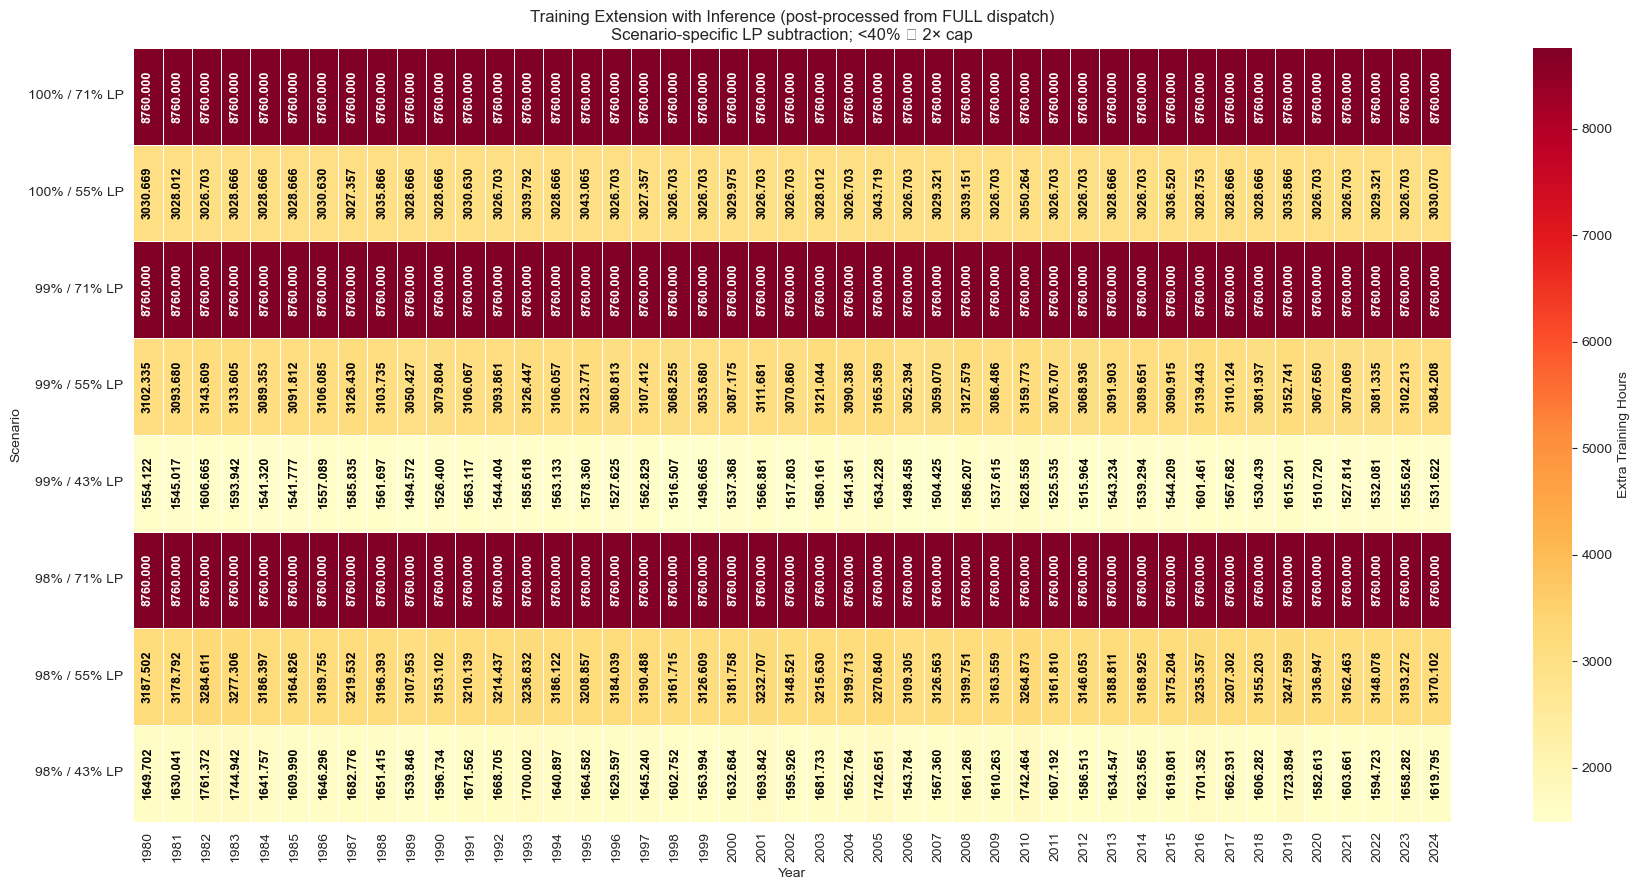

In [25]:
import os
import re
import glob
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# === Full-baseline dispatch folders by RDML ===
base_dispatch = {
    100: r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dcNevada2023",
    99:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metloadNevada2023",
    98:  r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_98metloadNevada2023", 
}

# === Scenarios to compute (label ⇒ (RDML, LP)) ===
# You can add/remove scenarios by editing this dict.
scenarios = {
    "100% / 71% LP": (100, 71),
    "100% / 55% LP": (100, 55),
    "99% / 71% LP":  (99, 71),
    "99% / 55% LP":  (99, 55),
    "99% / 43% LP":  (99, 43),
    "98% / 71% LP":  (98, 71),
    "98% / 55% LP":  (98, 55),
    "98% / 43% LP":  (98, 43),
}

# === Training extension interpolation (1.0..2.0×) ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100,  50,   0])
training_times = np.array([40000,42000,42500,45000,46000,50000,58000,70000,80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250
interpolator = interp1d(
    power_missing_fraction, extension_factors,
    kind='cubic', fill_value='extrapolate'
)

def ext_factor_from_percent(pct_available: float) -> float:
    """
    Training-time extension factor (×) from available power percent.
    If available power < 40%, force 2× (=> 1 extra hour per hour).
    """
    p = float(np.clip(pct_available, 0, 100))
    if p < 40.0:
        return 2.0
    missing_fraction = 1 - (p / 100.0)
    return float(interpolator(missing_fraction))

def find_year_files(folder: str) -> dict[int, str]:
    """Scan folder for dispatch_data_*.csv and return {year -> path}."""
    if not os.path.isdir(folder):
        return {}
    files = glob.glob(os.path.join(folder, "dispatch_data_*.csv"))
    year_map = {}
    for fp in files:
        m = re.search(r"dispatch_data_(\d{4})\.csv$", os.path.basename(fp))
        if m:
            year_map[int(m.group(1))] = fp
    return year_map

# === Discover files per scenario ===
scenario_year_files: dict[str, dict[int, str]] = {}
all_years: set[int] = set()
for label, (rdml, lp) in scenarios.items():
    folder = base_dispatch.get(rdml)
    year_map = find_year_files(folder) if folder else {}
    scenario_year_files[label] = year_map
    all_years.update(year_map.keys())

if not all_years:
    raise SystemExit("No dispatch_data_*.csv found in the provided RDML folders.")

years_sorted_desc = sorted(all_years, reverse=True)

# === Compute totals ===
heatmap_data = pd.DataFrame(index=years_sorted_desc, columns=scenarios.keys(), dtype=float)

for label, (rdml, lp) in scenarios.items():
    folder = base_dispatch.get(rdml)
    year_files = scenario_year_files.get(label, {})
    per_year_total = {}

    for year in years_sorted_desc:
        csv_path = year_files.get(year)
        if not csv_path:
            per_year_total[year] = np.nan
            continue

        try:
            df = pd.read_csv(csv_path)

            # Power Available (%) vs FULL baseline in the CSV
            df['Unmet (%)'] = (df['Unmet (kW)'] / df['Load (kW)']) * 100.0
            df['Power Available (%)'] = 100.0 - df['Unmet (%)']

            # Subtract inference LP once (post-processing), clip to [0, 100]
            df['Power Available Adjusted (%)'] = np.clip(df['Power Available (%)'] - float(lp), 0.0, 100.0)

            # Apply extension with <40% ⇒ 2× cap
            df['Training Time Extension (×)'] = df['Power Available Adjusted (%)'].apply(ext_factor_from_percent)
            df['Extra Training Hours'] = df['Training Time Extension (×)'] - 1.0

            total_extra = float(df['Extra Training Hours'].sum())
            per_year_total[year] = round(total_extra, 3)

            # Optional: write per-year CSV (rounded 3 d.p.)
            out_cols = [
                'Hour','Load (kW)','Unmet (kW)','Unmet (%)',
                'Power Available (%)','Power Available Adjusted (%)',
                'Training Time Extension (×)','Extra Training Hours'
            ]
            present = [c for c in out_cols if c in df.columns]
            if present:
                df_save = df[present].copy()
                for c in ['Unmet (%)','Power Available (%)','Power Available Adjusted (%)',
                          'Training Time Extension (×)','Extra Training Hours']:
                    if c in df_save.columns:
                        df_save[c] = df_save[c].astype(float).round(3)
                # Saves next to the source RDML folder
                df_save.to_csv(os.path.join(folder, f"{label.replace('%','pct').replace(' / ','_').replace(' ','_')}_training_ext_{year}.csv"), index=False)

        except Exception as e:
            print(f"Error processing {label} {year}: {e}")
            per_year_total[year] = np.nan

    heatmap_data[label] = pd.Series(per_year_total)

# === Plot heatmap (3 d.p.), vertical text, inverted x-axis, auto-contrast ===
plt.figure(figsize=(18, 9))
sns.set_style("whitegrid")

# Columns already newest→oldest (years_sorted_desc). We invert x-axis to show newest on the left.
ax = sns.heatmap(
    heatmap_data.T,
    cmap="YlOrRd",
    annot=heatmap_data.T.round(3),
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={'label': 'Extra Training Hours'},
    annot_kws={"fontsize": 9, "weight": "bold", "rotation": 90}
)

ax.invert_xaxis()
ax.set_title("Training Extension with Inference (post-processed from FULL dispatch)\nScenario-specific LP subtraction; <40% ⇒ 2× cap")
ax.set_xlabel("Year")
ax.set_ylabel("Scenario")

# Improve annotation contrast using actual colormap luminance
cmap = plt.get_cmap("YlOrRd")
vmin = np.nanmin(heatmap_data.values)
vmax = np.nanmax(heatmap_data.values)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

for text in ax.texts:
    try:
        val = float(text.get_text())
    except ValueError:
        continue
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299*r + 0.587*g + 0.114*b
    text.set_color("black" if luminance > 0.60 else "white")

plt.tight_layout()
plt.show()
